<a href="https://colab.research.google.com/github/sarangis/python_learning/blob/main/M4/M4_Additional_NB_01_Multimodal_Models__Without_OpenAI_API_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification Programme in Agentic and Generative AI
## A Programme by IISc and TalentSprint
### Additional Notebook: Multimodal Models (Without OpenAI API)

(Ungraded)

# I. Getting Started with Multimodal Models

## Objective

Experience how a multi-modal AI model can process text, images, and audio to generate meaningful outputs. The goal is to highlight how combining different modes enhances understanding and productivity compared to text-only models.


## Information

**Multimodality** refers to a model's ability to understand and generate content using various input types—such as ***text, images, audio, and video***. Multimodal models combine diverse data sources to interpret complex contexts, enabling more comprehensive and nuanced responses.

### Import Required Packages

In [16]:
import os
import base64
from PIL import Image
from io import BytesIO
from IPython.display import Audio

### Read the Groq API Key

Using the Groq API Key, you will have access to the OpenAI and Llama model, free of cost, under the [Free-tier](https://console.groq.com/docs/rate-limits#rate-limits).

This cell retrieves the Groq API key securely stored in Google Colab's Secrets (see 'key' icon on the leftmost panel of this notebook) and sets it as an environment variable `GROQ_API_KEY`. This is a recommended practice to avoid exposing your API key directly in the code.


* Go to https://console.groq.com/, and setup a Free account.

* Create a new API by visiting: https://console.groq.com/keys

* Save the key in Google Colab's Secrets
    ```
    Secret Name: GROQ_API_KEY
    Secret Value: Paste your Groq api key
    ```

* Read the key and save as an environment variable `GROQ_API_KEY`

In [17]:
# Save the key in Colab's Secrets then load from there

import os
from google.colab import userdata

os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')

**Create Groq Client**

This cell initializes the Groq client using the API key stored in the environment variable. This client object will be used to make API calls to OpenAI model.


In [18]:
# Install Groq library
!pip -q install groq

In [19]:
from groq import Groq

# Initialize Groq client
client = Groq()

## **1) Text $→$ Image** $\quad$ (Image generation)

### **Image generation with Gemini (aka Nano Banana)**

**Model:** `Gemini 2.5 Flash Image (aka Nano Banana)`

<br>

Gemini can generate and process images conversationally. You can prompt Gemini with text, images, or a combination of both allowing you to create, edit, and iterate on visuals with unprecedented control:

- **Text-to-Image:** Generate high-quality images from simple or complex text descriptions.

- **Image + Text-to-Image (Editing):** Provide an image and use text prompts to add, remove, or modify elements, change the style, or adjust the color grading.

- **Multi-Image to Image (Composition & Style Transfer):** Use multiple input images to compose a new scene or transfer the style from one image to another.

- **Iterative Refinement:** Engage in a conversation to progressively refine your image over multiple turns, making small adjustments until it's perfect.

- **High-Fidelity Text Rendering:** Accurately generate images that contain legible and well-placed text, ideal for logos, diagrams, and posters.



Try Nano Banana:

- Using [Google AI Studio >> Playground >> Image Generation >> Nano Banana](https://aistudio.google.com/u/1/prompts/new_chat?model=gemini-2.5-flash-image)

- Using [Gemini API](https://ai.google.dev/gemini-api/docs/image-generation?utm_source=AISgaias&utm_medium=email&utm_campaign=nano&utm_content=hero_start_building)


**1. Select Nano Banana (the free model option)**

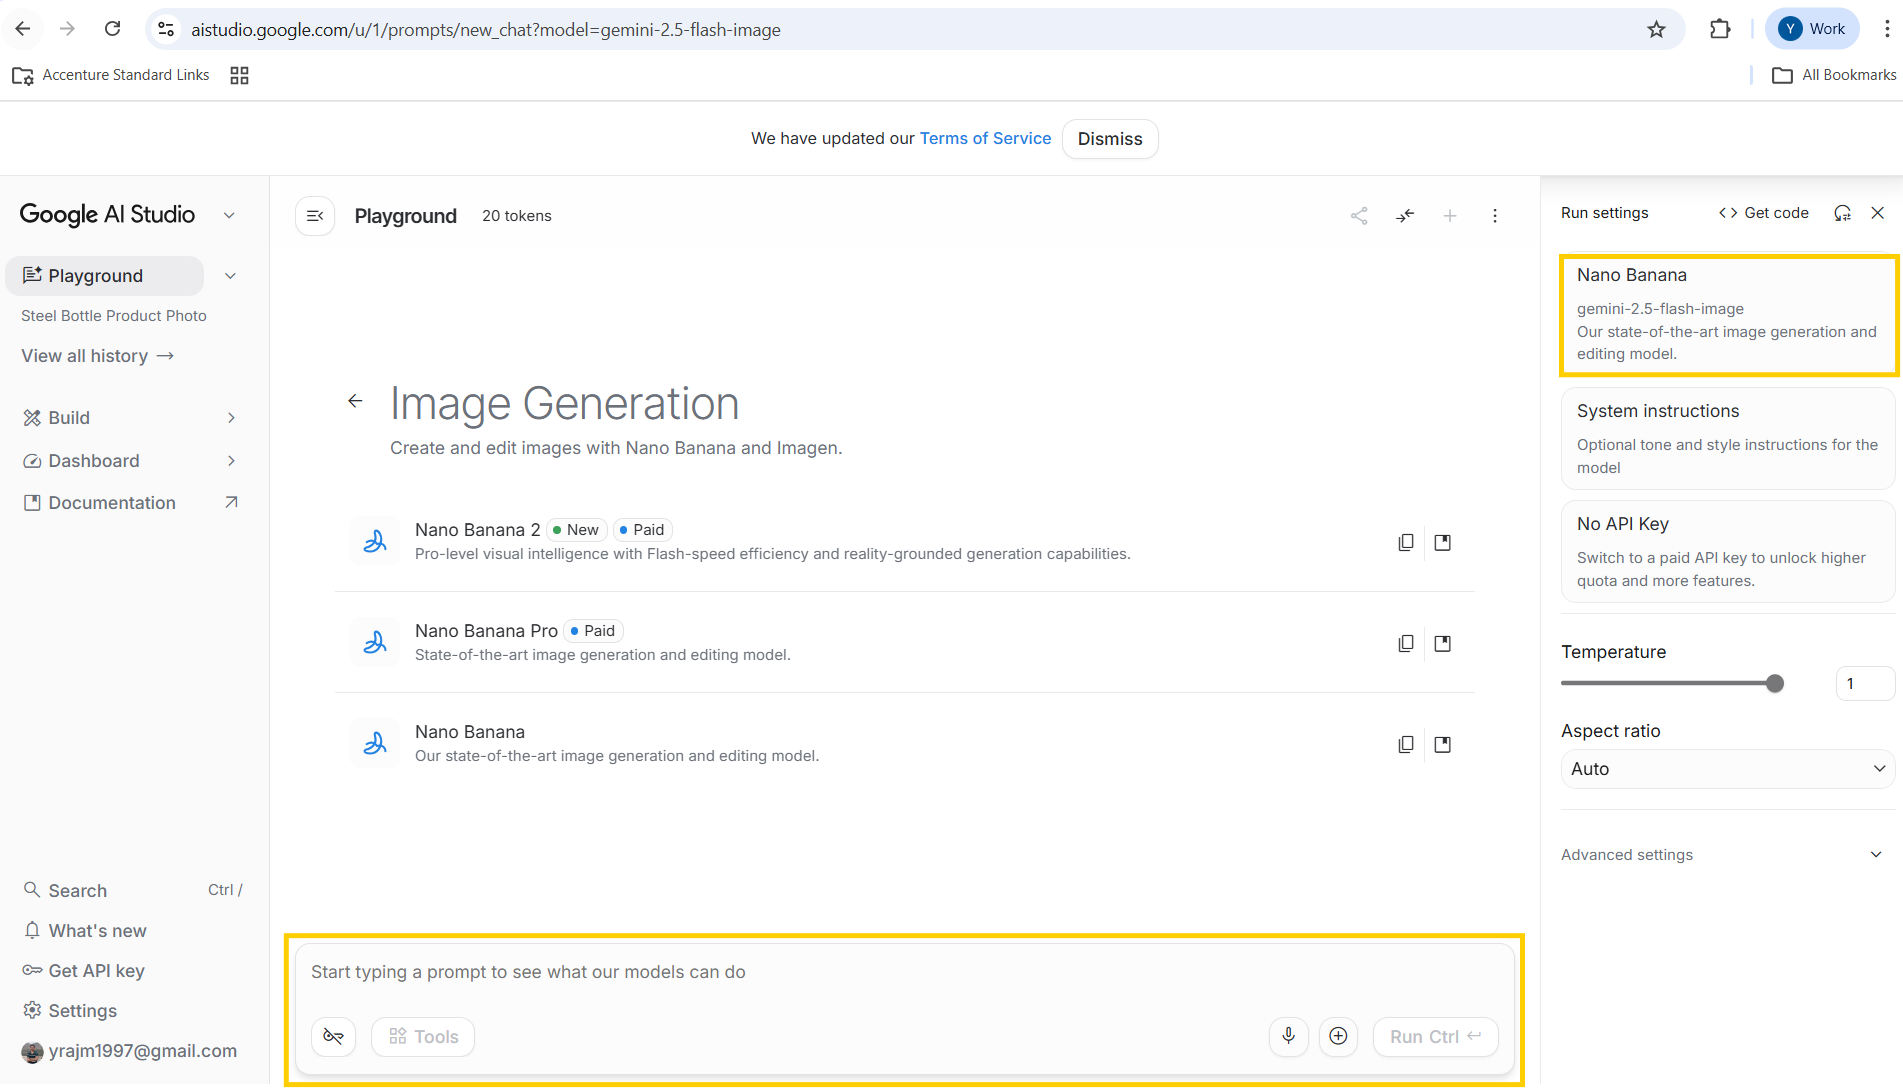

**2. Write your Prompt and Run**

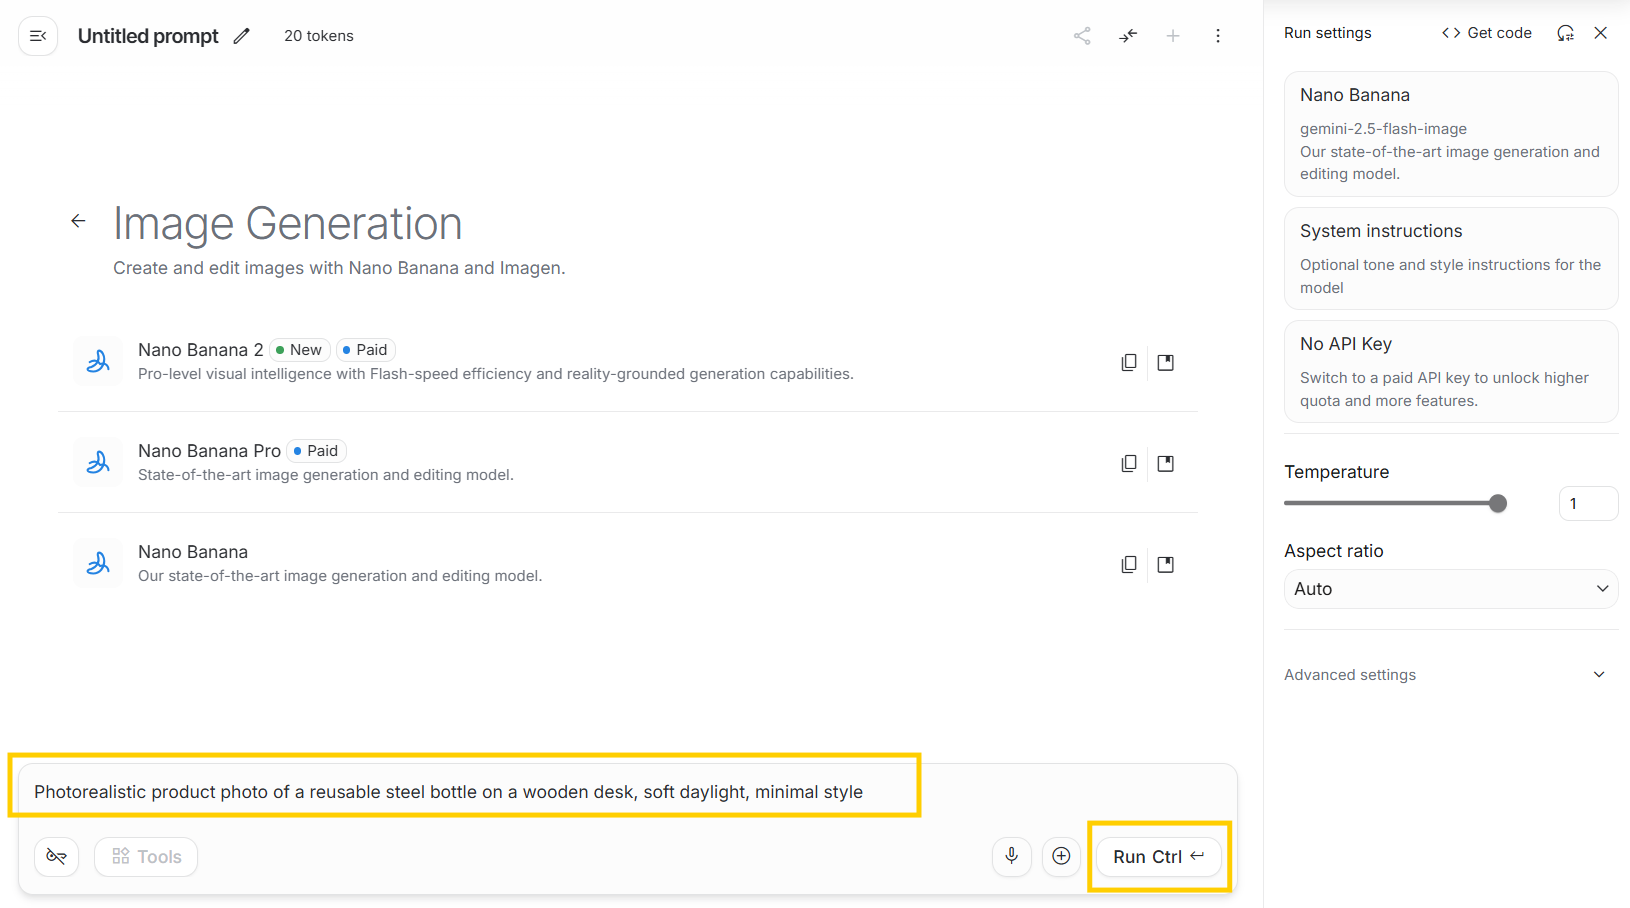

**3. Image should be generated**

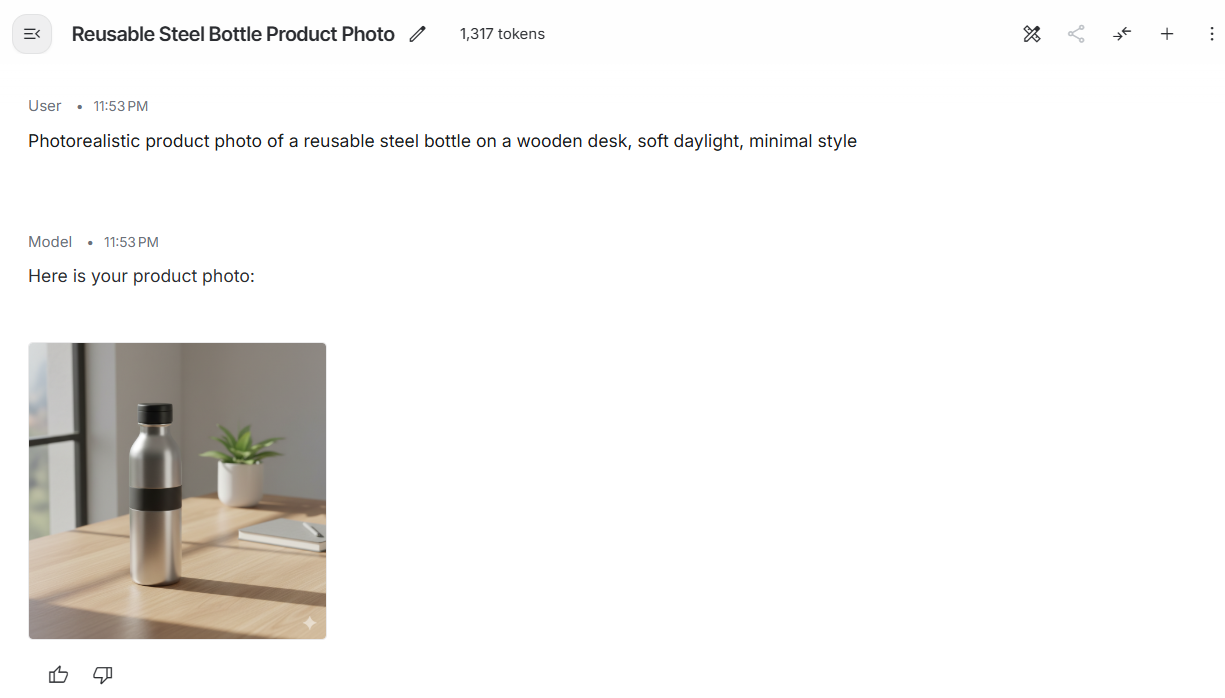

---
---

## **2) Text + Image $→$ Image $\quad$ (Edit images)**

**Model:** GPT Image (`gpt-image-1`)


**Item edit**

```
edit_prompt = "Put some water droplets on the bottle to make it appealing"
```

**1. Use Nano Banana model in playground, upload an image, write a prompt and Run**

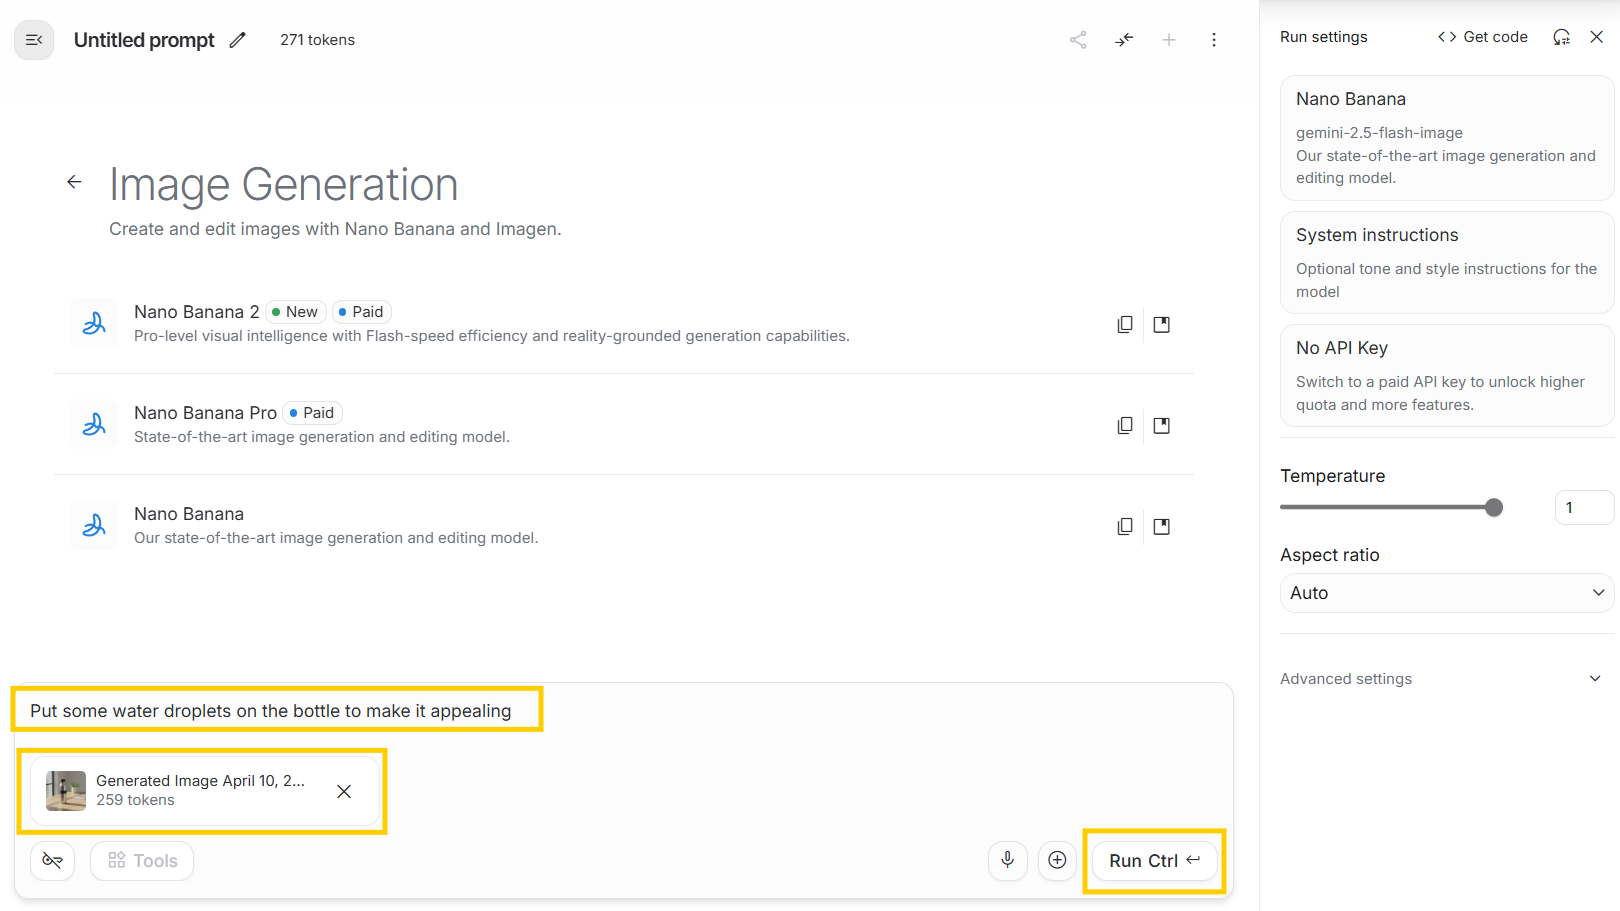

**2. New edited image should be generated**

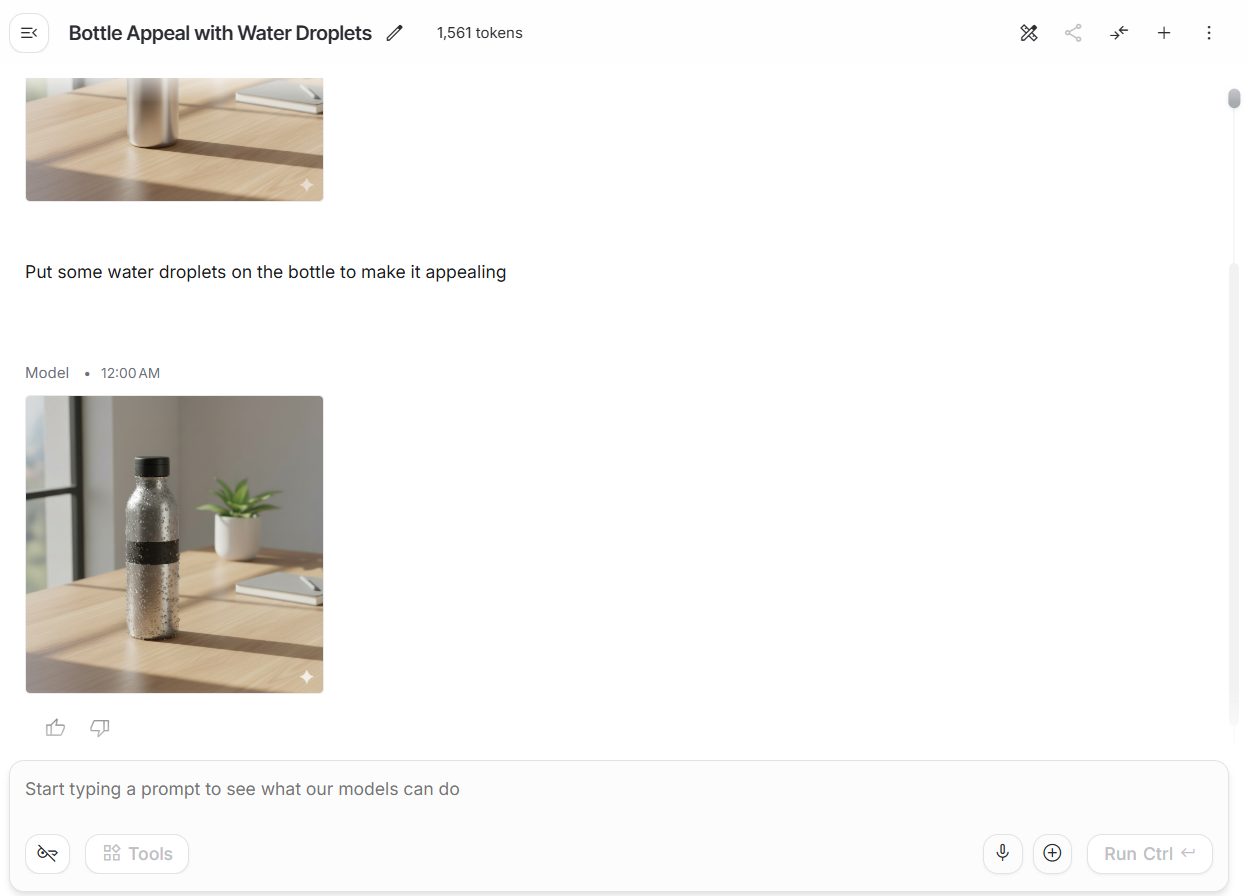

**Add item**

```
add_prompt = "Add a half-filled glass also near the bottle with water droplets on both objects"
```

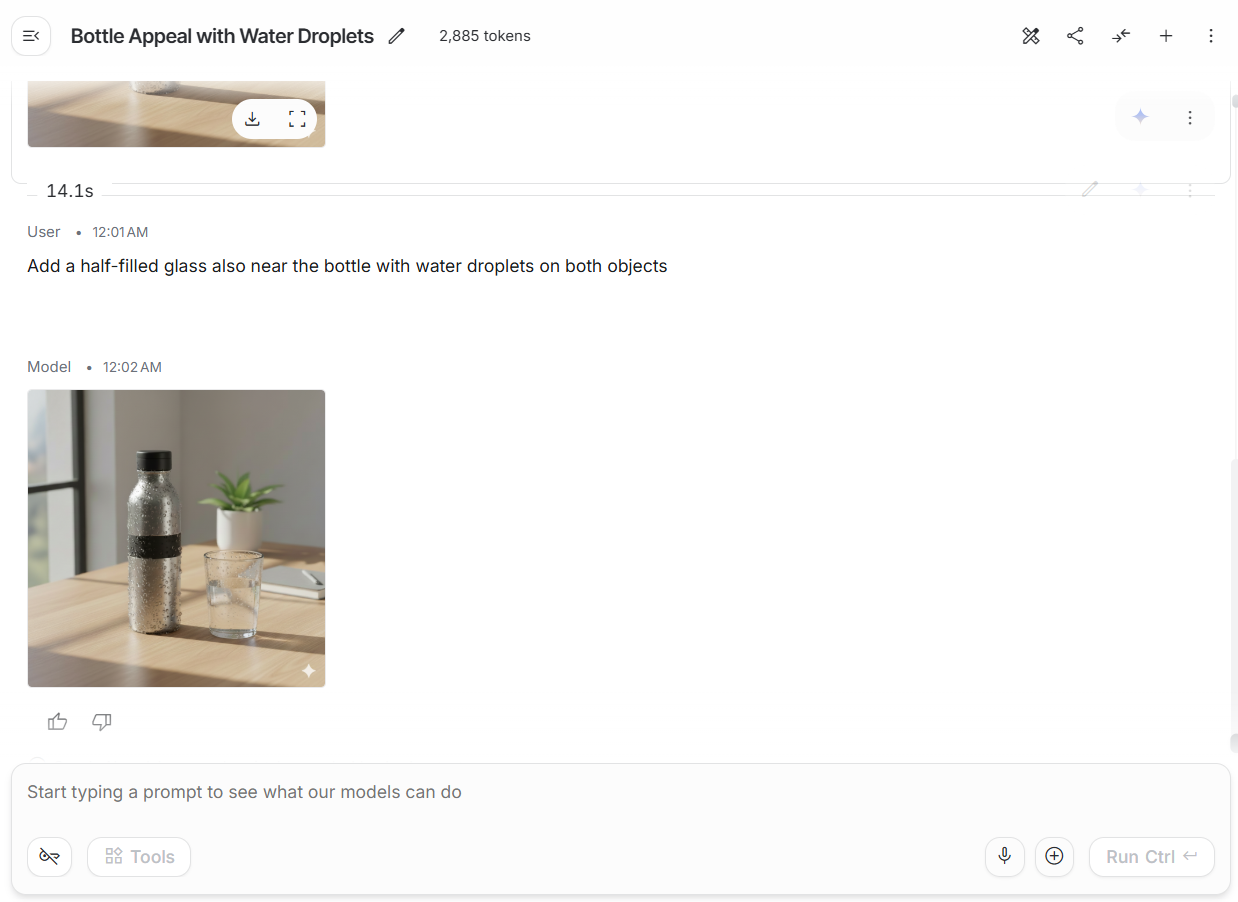

## **3) Text + Image $→$ Text** $\quad$ (Image understanding / OCR + reasoning)

Generative AI models capable of understanding and processing visual inputs.

**Model:** `meta-llama/llama-4-scout-17b-16e-instruct`


In [ ]:
# Download sample image

!gdown https://drive.google.com/uc?id=1UN3EcVk_GSK6YD8eBHFaw--gOoMwZs53

Downloading...
From: https://drive.google.com/uc?id=1UN3EcVk_GSK6YD8eBHFaw--gOoMwZs53
To: /content/Travel-1.jpg
100% 716k/716k [00:00<00:00, 61.3MB/s]


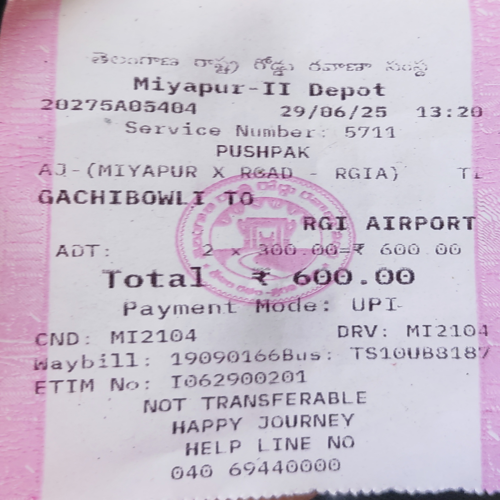

In [ ]:
# Check sample image
sample_img = Image.open("Travel-1.jpg").resize((500,500))
sample_img

In [ ]:
# Function to Analyze image

def analyze_image(image_path, prompt):

    # First, encode image file to base64 string
    with open(image_path, "rb") as image_file:
        base64_image = base64.b64encode(image_file.read()).decode('utf-8')

    # Then analyze the image
    response = client.chat.completions.create(
        model="meta-llama/llama-4-scout-17b-16e-instruct",
        messages=[
            {"role": "user",
            "content": [
                    {"type": "text", "text": "Extract Source, Destination, and Fare from the image"},
                    {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_image}",}}
                ]
            }
        ],
        max_tokens=50,
        temperature=0.2,

    )

    return response.choices[0].message.content


In [ ]:
prompt="Extract Source, Destination, and Fare from the image"

extracted_info = analyze_image(image_path="Travel-1.jpg", prompt=prompt)

print(extracted_info)

**Source:** Gachibowli 
**Destination:** RGI Airport
**Fare:** ₹600.00


## **4) Text $→$ Audio** $\quad$ (TTS: Text-to-Speech)

**Model:** `canopylabs/orpheus-v1-english`


The model `canopylabs/orpheus-v1-english` requires terms acceptance.

To accept the terms:

1. Go to this link: https://console.groq.com/playground?model=canopylabs/orpheus-v1-english

2. Click on ***accepted*** hyperlink

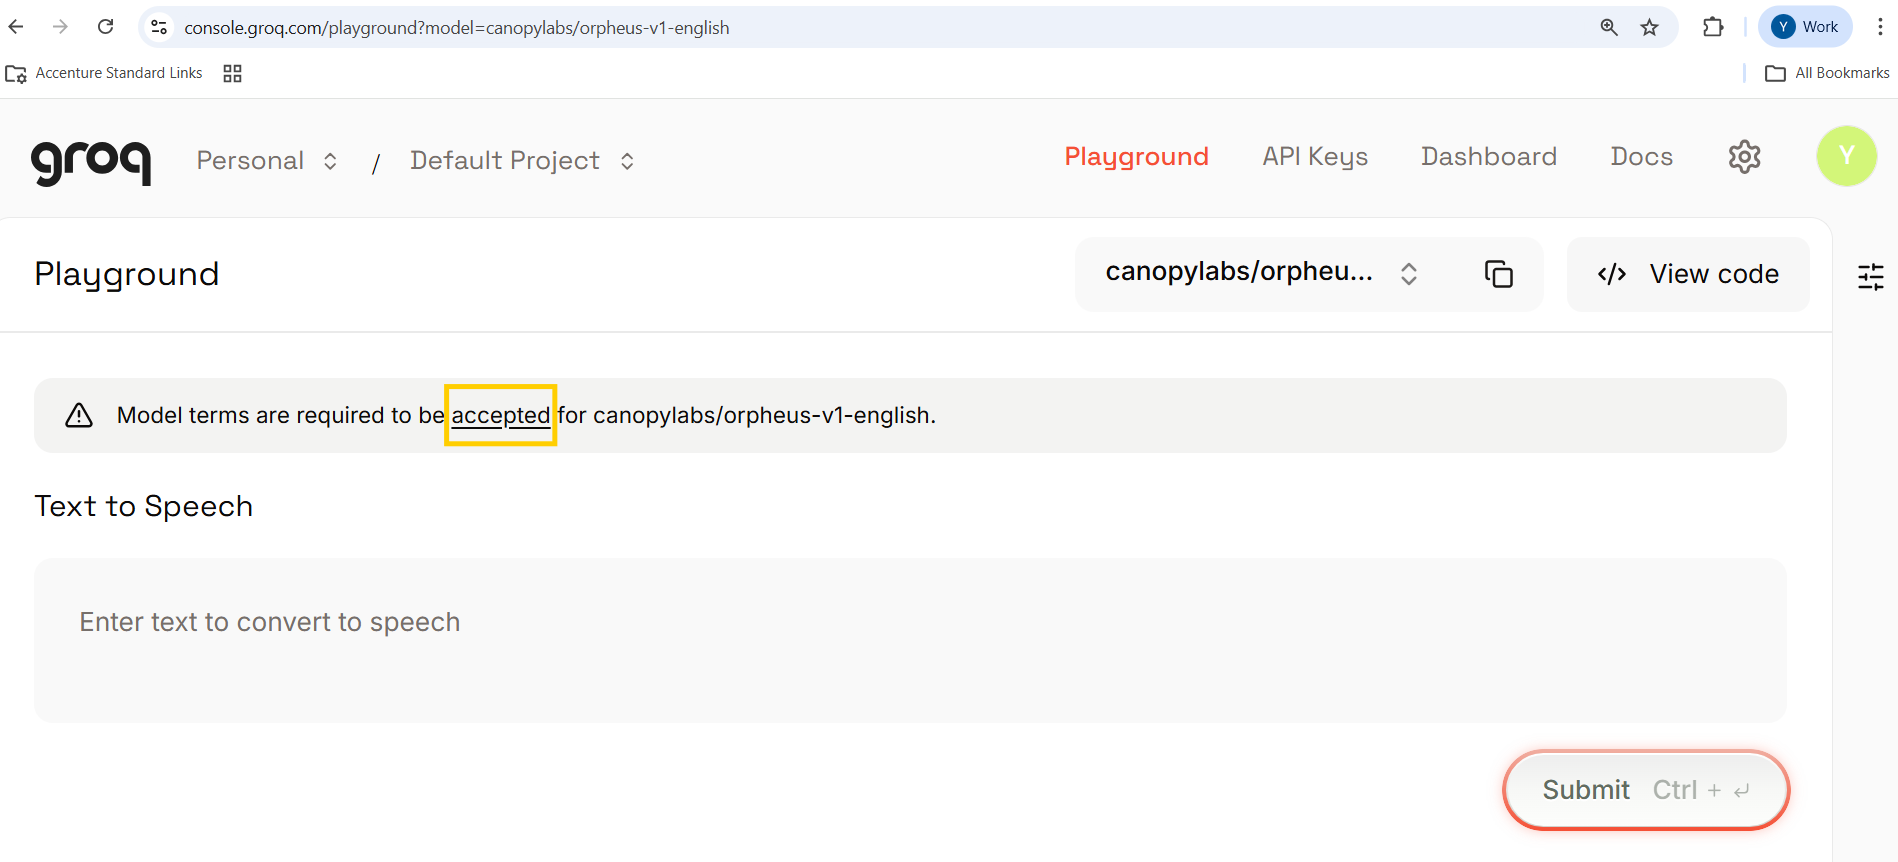

3. Select the checkbox and ***Accept Terms***.

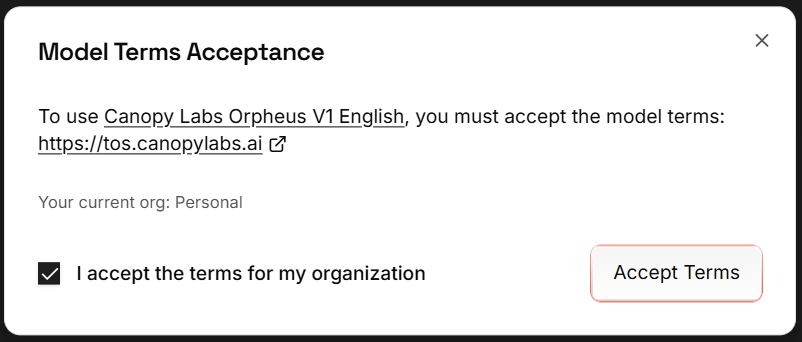

In [ ]:
# Function to play a MP3 file

from IPython.display import Audio

def play(filepath):
    print("Playing file: " + filepath)
    return Audio(filepath)

In [ ]:
# Text-to-Speech with Instructions

input_text = """Hello everyone! Today we're starting an exciting journey into the world of Generative AI.
How many of you have used ChatGPT or similar AI tools? Most of you right!
Today we'll understand not just how to use these tools, but why they represent the biggest technological shift since the internet.
"""

speech_file_path = "Intro.wav"


with client.audio.speech.with_streaming_response.create(
    model="canopylabs/orpheus-v1-english",
    voice="troy",      # other voices available: [autumn diana hannah austin daniel troy]
    input=input_text,
    response_format="wav",

) as response:
    response.stream_to_file(speech_file_path)

In [ ]:
# Play generated audio
play(speech_file_path)

Playing file: Intro.wav


In [ ]:
# Function for Text-to-Speech

def text_to_speech(input_text, speech_file_path):

    with client.audio.speech.with_streaming_response.create(
        model="canopylabs/orpheus-v1-english",
        voice="troy",      # other voices available: [autumn diana hannah austin daniel troy]
        input=input_text,
        response_format="wav"
    ) as response:
        response.stream_to_file(speech_file_path)

    return play(speech_file_path)


In [ ]:
text = "Hello team! The sprint demo starts at 4 PM in the main conference room."

text_to_speech(input_text = text,
               speech_file_path = "announcement.wav"
               )

Playing file: announcement.wav


## **5) Audio $→$ Text** $\quad$ (Transcribe: Speech-to-Text)

**Model:** `whisper-large-v3-turbo`

**Whisper**

Whisper is a general-purpose speech recognition model. It is trained on a large dataset of diverse audio and is also a multitasking model that can perform multilingual speech recognition, speech translation, and language identification.

In [ ]:
#@title Download a test audio
from IPython.display import clear_output
!wget -O audio.mp3 http://www.moviesoundclips.net/movies1/darkknightrises/darkness.mp3
clear_output()
!ls | grep 'audio.mp3'

audio.mp3


**Transcription**

In [ ]:
from IPython.display import Audio

# Play sample audio
Audio("audio.mp3")

In [ ]:
# Transcribe

# Open the audio file
with open("audio.mp3", "rb") as audio_file:
    # Create a transcription of the audio file
    transcription = client.audio.transcriptions.create(
        file=audio_file,                                 # Required audio file
        model="whisper-large-v3-turbo",                  # Required model to use for transcription
        language="en",                                   # Optional
        temperature=0.0,                                 # Optional
        response_format="text"
    )

transcription

" Oh, you think darkness is your ally. You merely adopted the dark. I was born in it. Molded by it. I didn't see the light until I was already a man. By then it was nothing to me but light."

In [ ]:
# Function for Speech-to-Text

def speech_to_text(audio_filepath):
    with open(audio_filepath, "rb") as audio_file:
        transcription = client.audio.transcriptions.create(
            file=audio_file,
            model="whisper-large-v3-turbo",
            language="en",
            temperature=0.0,
            response_format="text"
        )
    return transcription


In [ ]:
audio_text = speech_to_text("audio.mp3")
audio_text

" Oh, you think darkness is your ally. You merely adopted the dark. I was born in it. Molded by it. I didn't see the light until I was already a man. By then it was nothing to me but light."

## **6) Audio + Text $→$ Text** $\quad$ (Translate)

**Model:** `whisper-large-v3`


In [ ]:
#@title Download a sample French audio
from IPython.display import clear_output
!wget -O french.mp3 https://www.lightbulblanguages.co.uk/resources/audio/quelageastu.mp3
clear_output()
!ls | grep 'french.mp3'

french.mp3


**Translation**

In [ ]:
# Play audio
Audio("french.mp3")

In [ ]:
# Translate to English

# Audio file to use
filename = "french.mp3"

# Open the audio file
with open(filename, "rb") as file:
    # Create a translation of the audio file
    translation = client.audio.translations.create(
      file=(filename, file.read()),                 # Required audio file
      model="whisper-large-v3",                     # Required model to use for translation
      prompt="Translate to english",                # Optional
      response_format="text",                       # Optional
      temperature=0.0                               # Optional
    )

# Print the translation text
translation

" How old are you? I'm 4 years old I'm 5 years old I'm 6 years old I'm 7 years old I'm 8 years old I'm 9 years old I'm 10 years old I'm 11 years old"

## **7) Text $→$ Video** $\quad$ (Video generation)

**Model:** `Veo` (from Google)


Try Veo model:

(i) Go to [Google AI Studio >> Video Generation](https://aistudio.google.com/u/1/prompts/new_chat). Select a **Veo** model.

***Note**: Video generation with Veo in AI Studio earlier had limited free quota for testing, now the models are paid. To generate videos or to integrate Veo into your projects, please use the paid Gemini API.*


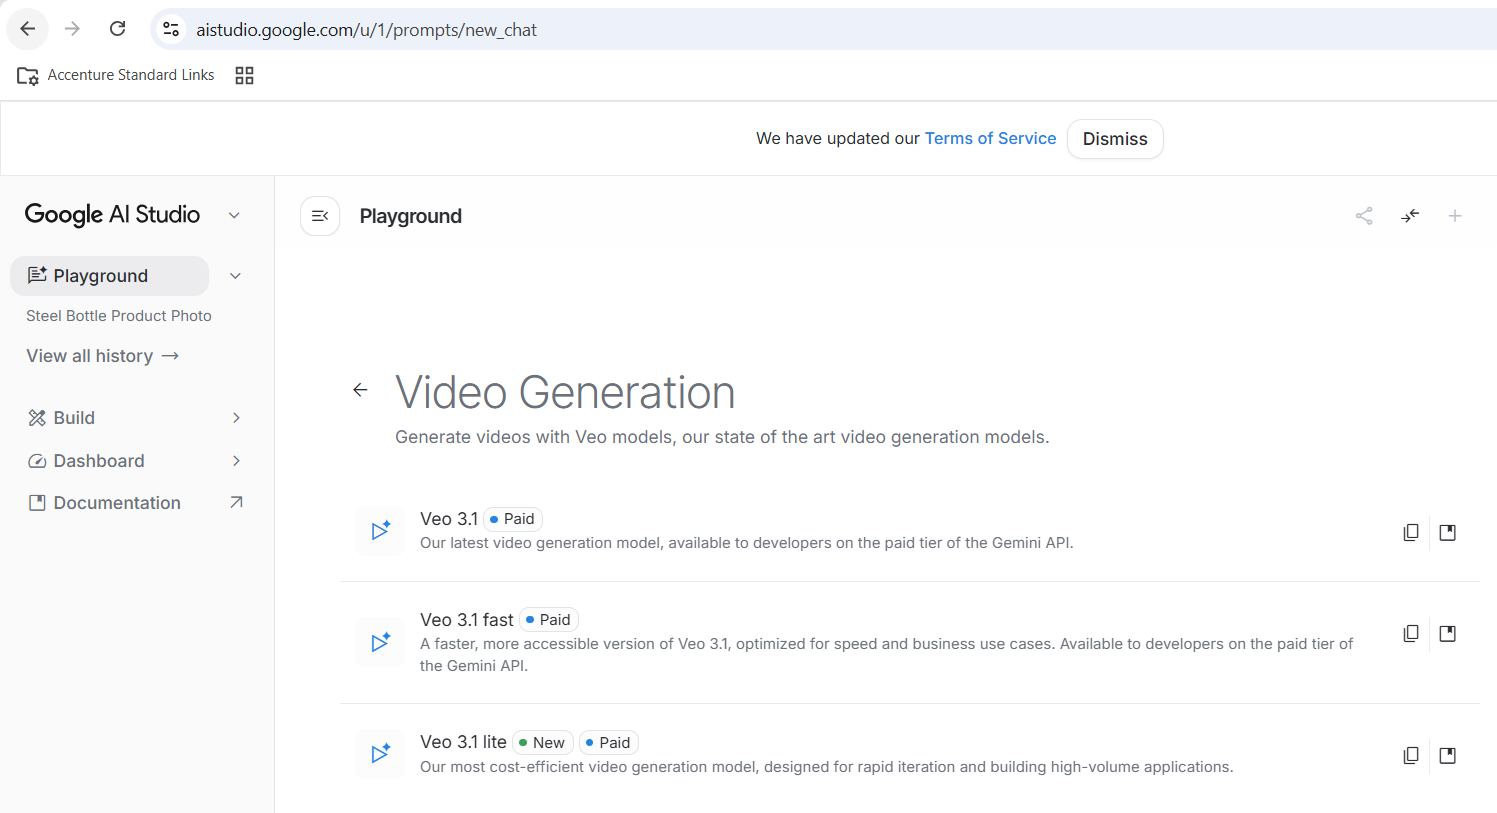

**(ii) Describe your video.** (It may ask you to enable you Google Drive to save the generated videos.)


<br>

![Google AI Studio - Veo2](https://drive.google.com/uc?id=1SuMXl3P18XnM7h448AMOyIbscchcy_cc)

---

For example:

<br>

![Google AI Studio - Prompt](https://drive.google.com/uc?id=12k_TF2vQG9dneT2hglDJxZ89GFgYdjWZ)

---

**(iii) Video generation will start.**

<br>

<img src='https://drive.google.com/uc?id=1ZuY7tpdpstPLGM_og3lAwbqWHM0Ha_t0' width=800px>

---


**(iv) Video should be generated successfully.** Check the generated video [here](https://drive.google.com/file/d/1iaXeDOm4pQAChFfBXt2JORPwjNZWhfg7/view?usp=sharing).

<br>

<img src='https://drive.google.com/uc?id=1a41PtU58fnlF5jepGdfaT2O38cFKnBau' width=800px>

---


To generate videos with Veo 3 using Gemini API, refer [here](https://ai.google.dev/gemini-api/docs/video?example=dialogue)

To check the Example prompts and output, refer [here](https://ai.google.dev/gemini-api/docs/video?example=dialogue#examples)

---
---

# II. Practice Task

(Ungraded)

Build an AI application to input Doctor-Patient conversation audio and output the list of medicines (if any).

**Intermediate Steps:**

- Read the audio file and perform transcription.
- Use the transcription text to extract the list of medicines (if any).
- Build a Gradio interface for the same.
    - Input: audio file
    - Output: list of medicines


For testing the application, you may use the sample audio file given below.

In [6]:
#@title Download a sample conversation audio
from IPython.display import clear_output
!gdown https://drive.google.com/uc?id=1a0rBPudaWZjZQsDXOH0Mpgw3Jp3oTCJ3
clear_output()
!ls | grep 'Doctor_Patient_Conversation_sample.mp3'

Doctor_Patient_Conversation_sample.mp3


In [ ]:
# Play sample audio file
play("Doctor_Patient_Conversation_sample.mp3")

Playing file: Doctor_Patient_Conversation_sample.mp3


**Gradio Implementation**

In [7]:
# Transcribe

# Open the audio file
with open("Doctor_Patient_Conversation_sample.mp3", "rb") as audio_file:
    # Create a transcription of the audio file
    transcription = client.audio.transcriptions.create(
        file=audio_file,                                 # Required audio file
        model="whisper-large-v3-turbo",                  # Required model to use for transcription
        language="en",                                   # Optional
        temperature=0.0,                                 # Optional
        response_format="text"
    )

transcription

" Doctor, I've been having these headaches almost every day, usually in the late afternoon. Do they feel sharp or more like a dull pressure? More like a dull pressure around my temples. Do you also feel dizziness or nausea? Sometimes a little nausea, yes. How's your sleep schedule? Honestly, not great. I sleep around 1 or 2 a.m. and wake up early for work. That could be contributing. I'll give you paracetamol 500 milligrams for the pain. If the nausea is troublesome, you can take ondansetron. But improving sleep will also help a lot. Okay, thank you, doctor."

### Using Groq client to suggest medicines

To use the Groq API, you'll need an API key. Add the key to the secrets manager under the "🔑" in the left panel. Give it the name `GROQ_API_KEY`. Then pass the key to the client:

Now, I will create a prompt using the existing `transcription` variable and call the Groq LLM to get medicine suggestions.

In [23]:
prompt = f"you are a expert doctor.Based on the following doctor-patient conversation transcription, please list any suggested medicines or treatments mentioned, along with the symptoms they are meant for. If no specific medicines are mentioned, suggest common over-the-counter options for the identified symptoms.\n\nTranscription: {transcription} . ***Generte output as json with key as symptom and value as medicine"

response = client.chat.completions.create(
    model="openai/gpt-oss-20b",
    messages=[
        {"role": "user", "content": prompt}
    ]
)
print(response)
print(response.choices[0].message.content)

ChatCompletion(id='chatcmpl-23a24d67-f6d4-4d7f-9b4a-86bfb82d9875', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='```json\n{\n  "headache": "Paracetamol 500 mg",\n  "nausea": "Ondansetron"\n}\n```', role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning='We need to produce JSON where keys are symptoms and values are medicine. In transcript: symptoms: headache (dull pressure), nausea, dizziness maybe. The doctor suggested paracetamol 500 mg for pain (headache) and ondansetron for nausea. Also improving sleep. So output JSON with key "headache" value "paracetamol 500 mg"; key "nausea" value "ondansetron". Also maybe "dizziness" but not specifically mentioned. Probably only those two. Provide JSON. Ensure valid JSON.', tool_calls=None))], created=1775902734, model='openai/gpt-oss-20b', object='chat.completion', mcp_list_tools=None, service_tier='on_demand', system_fingerprint='fp_976a85d17a', usage=Compl

### Suggesting Medicine based on Transcription

Now, let's process the transcription to identify symptoms and suggest relevant medications. This will involve keyword extraction and a simple rule-based system.

### Using Gemini API to suggest medicines

Now, initialize the Generative Model and create a prompt using the existing `transcription` variable to ask for medicine suggestions.

---

<center>$END$</center>

---